In [11]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join("../")))
import numpy as np
import matplotlib.pyplot as plt
from src.utilities import timer
from src.simulation import Simulation
from src.plot.plot_tools import plot_seismogram
from src.config import Config
from src.layers import create_layers_from_interfaces

In [12]:
config = Config(
    n_receivers=57, x_min=0., x_max=700.,
    z_rec=75., z_src=50., x_src=100., nq_prop=512, f0=10.,
    total_time=1.024, delay=0.1, epsilon=1.0,
    source_deriv=True, free_surface=True,
)
sim = Simulation(config)

In [13]:
# example from TOYxDAC_TIME
z_interfaces = np.array([0.0, 100.0, 200.0, 250.0, 350.0, 450.0, 550.0, 650.0, 700.0])
vp = np.array([1505.0, 1603.0, 1749.0, 2019.0, 2179.0,
                   1900.0, 2265.0, 3281.0])
rho = np.full_like(vp, 2000.0)
layers = create_layers_from_interfaces(z_interfaces, vp, rho)

In [14]:
import numba
numba.set_num_threads(16)
print("numba is using ", numba.get_num_threads() , " threads")

numba is using  16  threads


In [20]:
d_cal, _ = sim.forward(layers, timing=True)

reflectivity map elapsed: 0.11 s
quadrature elapsed: 0.22 s
Sommerfeld quadrature elapsed: 0.38 s


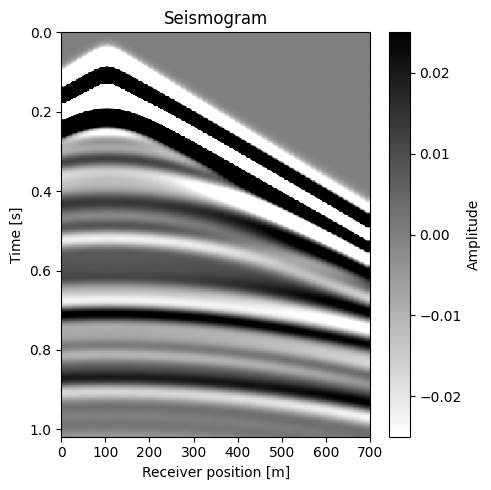

In [16]:
d_cal_seis = d_cal[0, :, :]
d_cal_seis = d_cal_seis / np.max(np.abs(d_cal_seis))  # normalise
plot_seismogram(
    d_cal_seis.T, sim.acq.xr, sim.param.time,
    vmin=-0.025, vmax=0.025, cmap='gray_r', ncolors=256, figsize=(5, 5),
)


(57, 164)


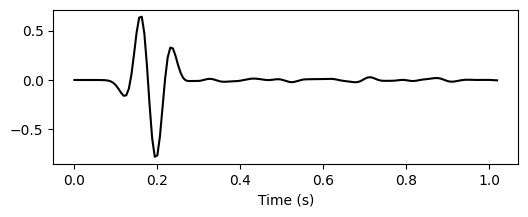

In [17]:
print(d_cal_seis.shape)
plt.figure(figsize=(6, 2))
plt.plot(sim.param.time, d_cal_seis[0, :], 'k-')
plt.xlabel('Time (s)')
plt.show()


(2048,)


Text(0.5, 0, 'Time (s)')

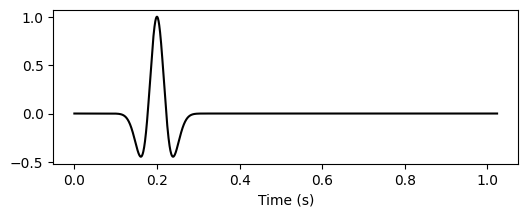

In [18]:
from src.utilities import ricker_wavelet
dt = 0.0005
nt = 2048
time = np.arange(nt) * dt
source_time = ricker_wavelet(time, config.f0)
print(source_time.shape)
plt.figure(figsize=(6, 2))
plt.plot(time, source_time, 'k-')
plt.xlabel('Time (s)')

#source_32 = source_time.astype(np.float32)
# Save to binary file
#filename = "fricker.bin"
#source_32.tofile(filename)
#print(f"File {filename} saved with {source_32.nbytes} bytes.")